In [1]:
import torch
import random
from pathlib import Path
import matplotlib.pyplot as plt
from ultralytics import YOLO, settings
import time

In [2]:

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print("CUDA:", torch.version.cuda)

True
NVIDIA GeForce RTX 4060 Laptop GPU
CUDA: 12.1


In [3]:
current_dir=Path.cwd()
if current_dir.name=="notebook":
    project_root=current_dir.parent
else:
    project_root=current_dir
models_dir=project_root/"models"
output_dir=project_root/"outputs"/"yolo"
output_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)
settings.update({
    "weights_dir": str(models_dir)
})

In [4]:


# train
pretrained_path=project_root/"models"/"yolo26s.pt"
model=YOLO(str(pretrained_path))
start=time.perf_counter()
model.train(
    data=str(project_root/"data_7class.yaml"),
    epochs=100,
    imgsz=640,
    batch=8,
    device=0,
    patience=15,
    amp=True,
    project=str(output_dir),
    name="Rail_Defect_Detect_7class",
    cache=False,
    workers=8, 
    seed=42,
    deterministic=True
)

elapsed=time.perf_counter()-start
print(f"Training time: {elapsed/60:.2f} minutes.")

New https://pypi.org/project/ultralytics/8.4.170 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.161  Python-3.12.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\Kun Bi\Desktop\rail_yolo_object_identification\data_7class.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01

In [5]:
# # load best model
best_model=YOLO(model.trainer.best)

In [6]:
# Evaluate on test dataset
metrics=best_model.val(
    data=str(project_root/"data_7class.yaml"),
    split="test",
    imgsz=640,
    device=0,
    project=str(output_dir),
    plots=True,
    name="Rail_Defect_validation_7class"
    )


Ultralytics 8.4.161  Python-3.12.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO26s summary (fused): 120 layers, 9,467,889 parameters, 0 gradients, 20.8 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 94.926.3 MB/s, size: 64.1 KB)
val: Scanning C:\Users\Kun Bi\Desktop\rail_yolo_object_identification\data_7class\test\labels.cache... 291 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 291/291  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 1.1it/s 17.7s0.1s
                   all        291       1475      0.423      0.432      0.379      0.138
           Corrugation         92        298      0.399      0.523       0.46      0.179
                Cracks         84        234      0.416      0.252      0.284     0.0904
               Flaking         70        157      0.341      0.395      0.295      0.115
              Shelling         92        268      0.571      0.545     

In [7]:
print(f"Precision: {metrics.box.mp}")
print(f"Recall: {metrics.box.mr}")
print(f"mAP50: {metrics.box.map50}")
print(f"mAP50-95: {metrics.box.map}")

Precision: 0.4229179852195691
Recall: 0.43245579133659434
mAP50: 0.37916423077891526
mAP50-95: 0.13840692066918234


In [8]:
print(metrics.box.maps)

[    0.17926    0.090432     0.11468     0.20142     0.13839     0.14295     0.10173]


In [9]:
# make prediction on 5 test images
test_dir=Path(project_root/"data_7class/test/images")
test_images=[
    image for image in test_dir.iterdir()
    if image.suffix.lower() in [".jpg"]
]
random.seed(42)

sample_images=random.sample(
    test_images,
    min(5, len(test_images))
)

sample_images

[WindowsPath('c:/Users/Kun Bi/Desktop/rail_yolo_object_identification/data_7class/test/images/20231018_113043_mp4-0268_jpg.rf.308f8ac457fb8a59cc090a6335f99555.jpg'),
 WindowsPath('c:/Users/Kun Bi/Desktop/rail_yolo_object_identification/data_7class/test/images/20231018_112728_mp4-0214_jpg.rf.56f3f591495243dbb3f823786c603227.jpg'),
 WindowsPath('c:/Users/Kun Bi/Desktop/rail_yolo_object_identification/data_7class/test/images/Rail_1_mp4-0079_jpg.rf.ab6aea66470ed5632b95dd6a1492bdda.jpg'),
 WindowsPath('c:/Users/Kun Bi/Desktop/rail_yolo_object_identification/data_7class/test/images/20231018_120709_mp4-0181_jpg.rf.b8bfc6509d5260d40b294e7bf3eb213b.jpg'),
 WindowsPath('c:/Users/Kun Bi/Desktop/rail_yolo_object_identification/data_7class/test/images/20231018_114952_mp4-0488_jpg.rf.35b5626dd30141138e258a05b592c9d0.jpg')]

In [10]:
#### Make prediction

In [11]:
results=best_model.predict(
    source=[str(image) for image in sample_images],
    imgsz=640,
    conf=0.25,
    device=0,
    project=str(output_dir),
    name="Rail_Defect_Predictions_7class"
)


0: 640x640 1 Flaking, 3 Spallings, 4.6ms
1: 640x640 3 Corrugations, 3 Flakings, 1 Spalling, 4.6ms
2: 640x640 3 Shellings, 4.6ms
3: 640x640 (no detections), 4.6ms
4: 640x640 1 Flaking, 2 Wheel-Burns, 4.6ms
Speed: 2.1ms preprocess, 4.6ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


In [12]:
#### Display results

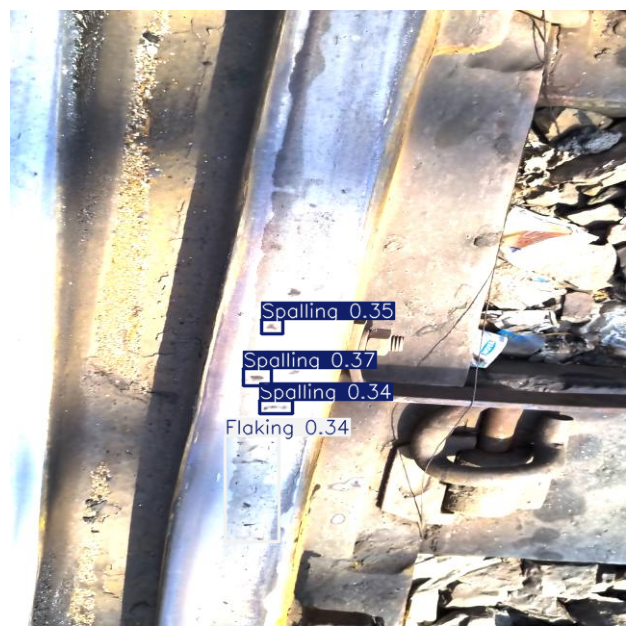

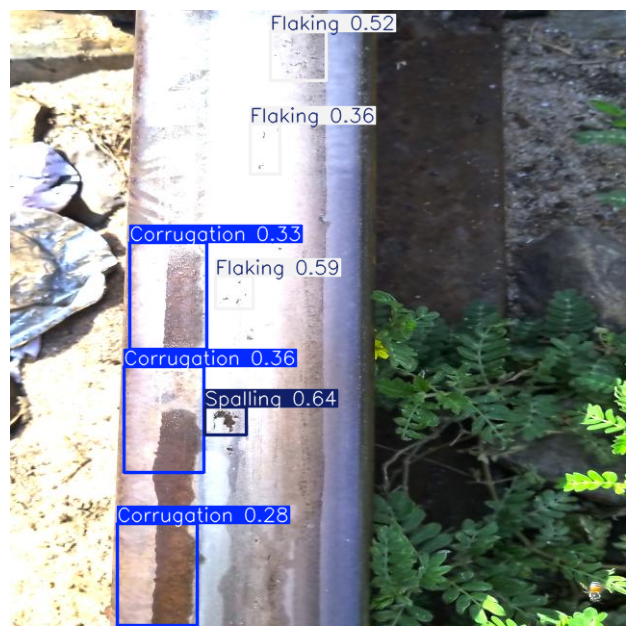

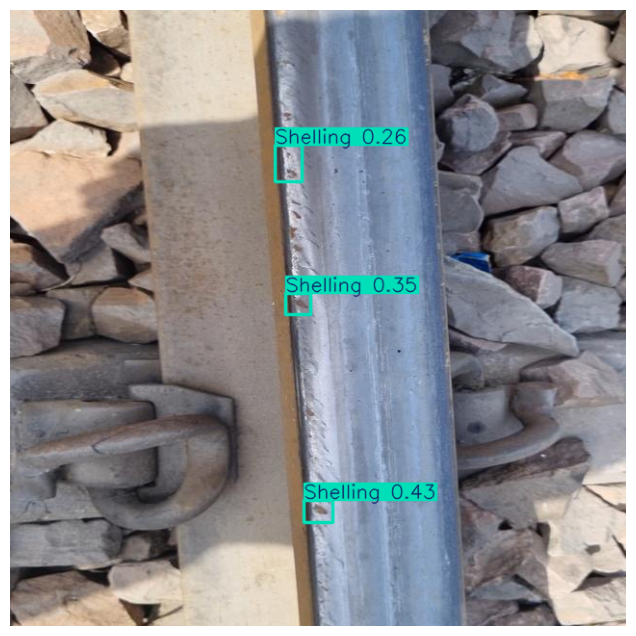

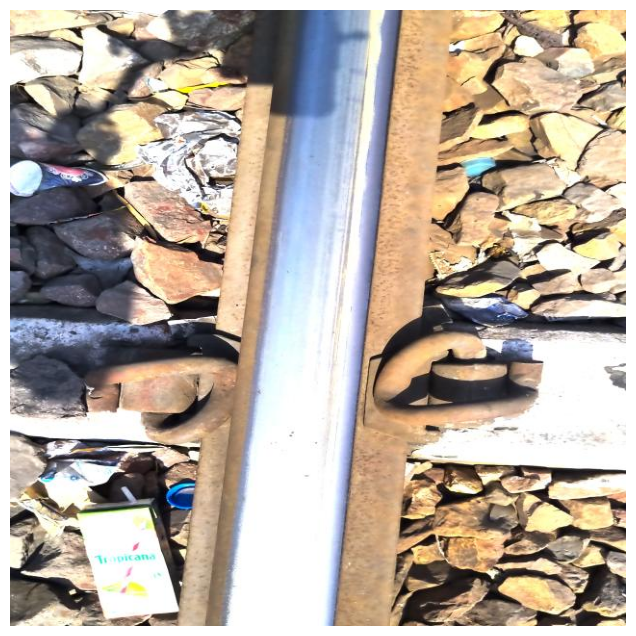

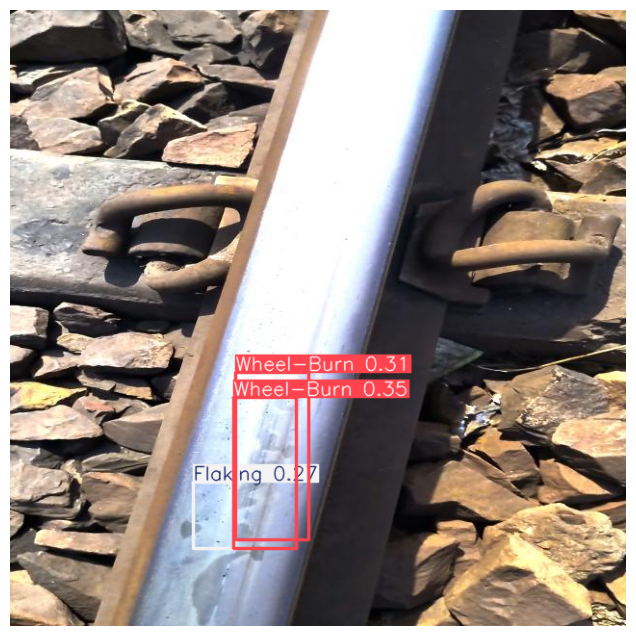

In [13]:
for result in results:
    predicted_images=result.plot()
    plt.figure(figsize=(10,8))
    plt.imshow(predicted_images[..., ::-1])
    plt.axis("off")
    plt.show()

In [16]:
import pandas as pd

df = pd.read_csv("../outputs/yolo/Rail_Defect_Detect_7class-7/results.csv")

print("Epochs completed:", len(df))
print(df.tail())

Epochs completed: 42
    epoch     time  train/box_loss  train/cls_loss  train/l1_loss  \
37     38  4202.84         1.90559         1.74968        0.00920   
38     39  4304.39         1.88923         1.72164        0.00902   
39     40  4401.24         1.89229         1.68442        0.00896   
40     41  4501.73         1.89038         1.66761        0.00900   
41     42  4598.43         1.88128         1.67015        0.00886   

    metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
37               0.41473            0.38957           0.34789   
38               0.43163            0.38586           0.34409   
39               0.44213            0.38621           0.35294   
40               0.40502            0.41216           0.33316   
41               0.42939            0.39284           0.34518   

    metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/l1_loss    lr/pg0  \
37              0.12596       2.21937       2.24339      0.01170  0.000576   
38              0